## Import the dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# DATA EXPLORATION

In [3]:
df.shape

(891, 12)

In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# DATA CLEANING

### NULL VALUES

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df=df.drop("Cabin",axis=1)

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [10]:
df["Age"].skew()

0.38910778230082704

In [11]:
df["Age"]=df["Age"].fillna(df["Age"].mean())


In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [13]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])


In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Duplicate value

In [15]:
print(df.duplicated().sum())

0


# DATA ANALYSIS

In [16]:
df["PassengerId"].count()

891

<Axes: >

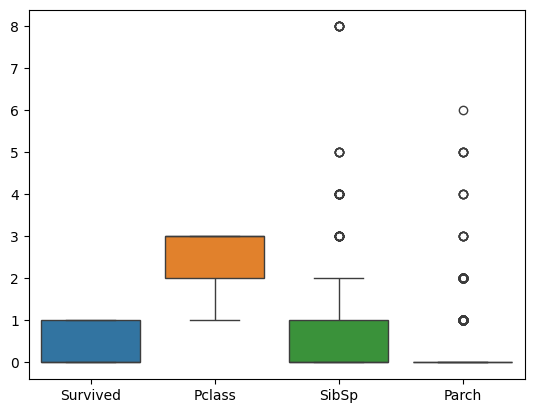

In [17]:
sns.boxplot([df[f"Survived"],df["Pclass"],df["SibSp"],df["Parch"]])


In [18]:
import numpy as np 
a=df.select_dtypes(include=np.number)

In [19]:
a


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.000000,1,0,7.2500
1,2,1,1,38.000000,1,0,71.2833
2,3,1,3,26.000000,0,0,7.9250
3,4,1,1,35.000000,1,0,53.1000
4,5,0,3,35.000000,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000
887,888,1,1,19.000000,0,0,30.0000
888,889,0,3,29.699118,1,2,23.4500
889,890,1,1,26.000000,0,0,30.0000


In [20]:
for i in a:
    q1=a[i].quantile(0.25)
    q2=a[i].quantile(0.50)
    q3=a[i].quantile(0.75)

In [21]:
IQR=q3-q1

In [22]:
IQR

23.0896

In [23]:
Uw=q3+1.5*IQR
Lw=q1-1.5*IQR

In [24]:
outliers=((a[i]>Uw)|(a[i]<Lw))


In [25]:
print(outliers.sum())

116


In [26]:
a.loc[(a[i]>Uw)|(a[i]<Lw),i]=q2

In [27]:
print(outliers.sum())

116


In [28]:
# Data Analysis
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [29]:
print(df["PassengerId"].count())

891


### There were 891 passengers on the ship

In [30]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

### Most of the customers died in the incident 

In [31]:
a=df.groupby("Sex")["Survived"].mean()*100


### Female survived most in the incident

In [32]:
b=pd.DataFrame(df.groupby("Pclass")["Survived"].mean()*100)
b

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


### Passengers from the class 1 survived more

### BINING

In [33]:
bins=[0,18,40,80]
labels=["Child","Adult","Old"]
df["AgeGroup"]=pd.cut(df["Age"],bins=bins,labels=labels)

In [34]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Adult


In [35]:
c=pd.DataFrame(df.groupby("AgeGroup")["Survived"].mean()*100)
c

C:\Users\prati\AppData\Local\Temp\ipykernel_11416\2550197926.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  c=pd.DataFrame(df.groupby("AgeGroup")["Survived"].mean()*100)


,Survived
AgeGroup,
Child,50.359712
Adult,36.046512
Old,36.666667


### Child survived more in the incident

In [36]:
df.sort_values(by="Fare",ascending=False).head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C,Adult
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C,Adult
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C,Adult
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,S,Adult
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,S,Adult


### The customers who are paying the more, surviving the more

In [37]:
df["FAmilyMembers"]=df["SibSp"]+df["Parch"]

In [38]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup,FAmilyMembers
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Adult,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Adult,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Adult,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Adult,0


In [39]:
df["FAmilyMembers"].sum()

806

### 90% of the passengers were the family members

In [40]:
df["Name"].str.contains("Mr.").sum()

647

# DATA VISULALISATION

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

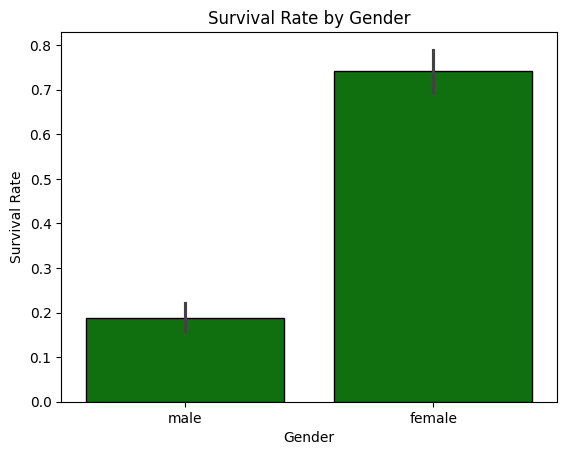

In [44]:
sns.barplot(x="Sex", y="Survived", data=df,color="green", edgecolor="black")
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

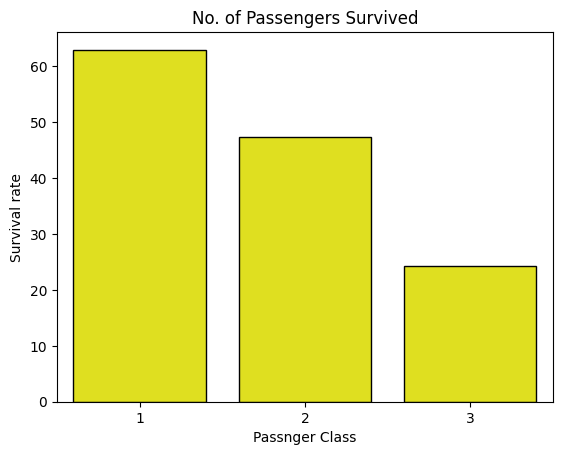

In [45]:
sns.barplot(x="Pclass",y="Survived",data=b,color="yellow",edgecolor="black")
plt.title("No. of Passengers Survived")
plt.xlabel("Passnger Class")
plt.ylabel("Survival rate")
plt.show()

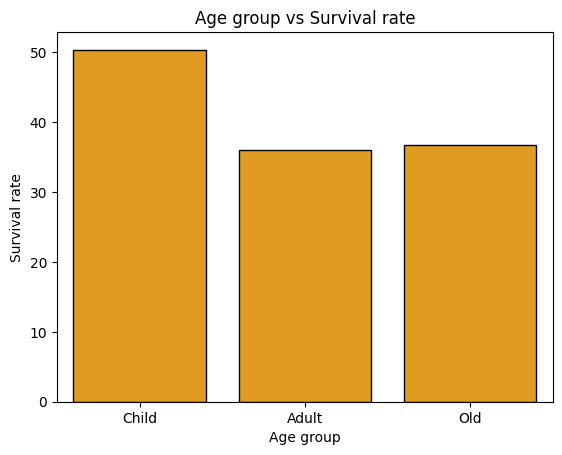

In [48]:
sns.barplot(x="AgeGroup",y="Survived",data=c,color="orange",edgecolor="black")
plt.title("Age group vs Survival rate")
plt.xlabel("Age group")
plt.ylabel("Survival rate")
plt.show()

# DASHBOARD

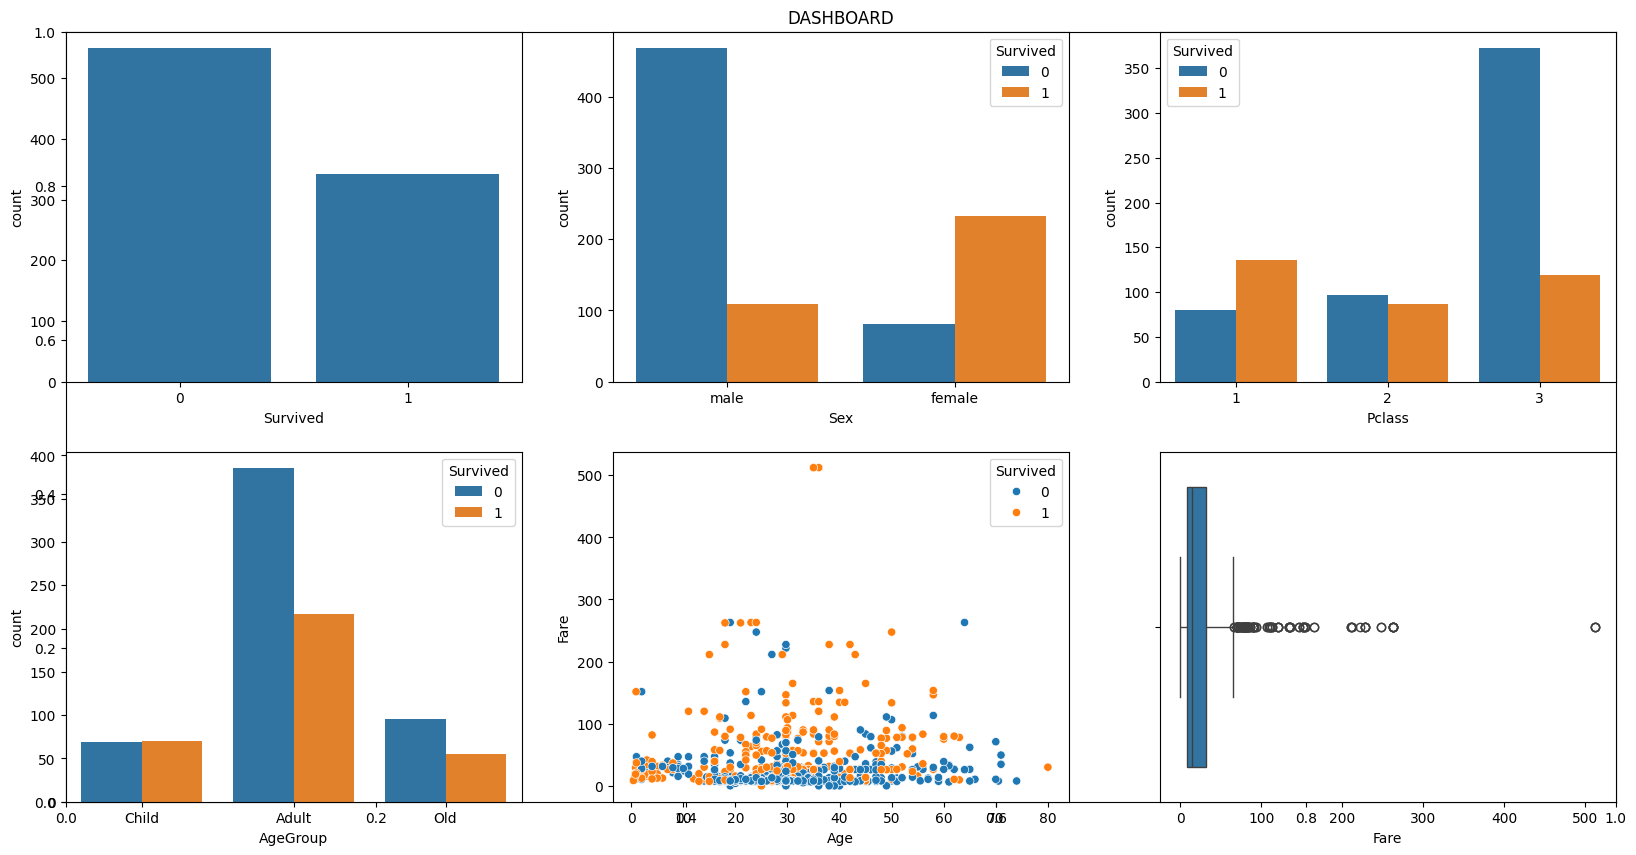

In [50]:
plt.figure(figsize=(20,10))
plt.title("DASHBOARD")
plt.subplot(2,3,1)
sns.countplot(x="Survived",data=df)
plt.subplot(2,3,2)
sns.countplot(x="Sex",hue="Survived",data=df)
plt.subplot(2,3,3)
sns.countplot(x="Pclass",hue="Survived",data=df)
plt.subplot(2,3,4)
sns.countplot(x="AgeGroup",hue="Survived",data=df)
plt.subplot(2,3,5)
sns.scatterplot(x="Age",y="Fare",hue="Survived",data=df)
plt.subplot(2,3,6)
sns.boxplot(x="Fare",data=df)
plt.show()

# DATA STORY TELLING

### 1. Most people have died in the incident.
### 2. Mostof the males died in the incident.
### 3. MOst of the people are survived from passenger class 1
### 4. Survival rate of the children are more as compared to adults and olds.
### 5. People who are paying more, surviving the more.
### 6. Around 20 people are paying more than the average people.